# Generate 3D mask from shape file

The mask dimensions are:
  - `region`: id of the region
  - `lat`: latitude
  - `lon`: longitude

The value in each cell corresponds to the share of the region (from 0 to 1) in the cell area.

The mask is saved in a NetCDF file with the metadata of the shape file in a JSON string under the attribute `metadata`.
The other attributes are: `transform`, `crs`, `resolution`, `description`.

Romain THOMAS - romain.thomas@polito.it

2026

## Libraries

In [1]:
import json
import logging
import os
import time
import webbrowser

import dask
from dask import delayed
from dask.distributed import Client, LocalCluster
from dotenv import load_dotenv
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.io import MemoryFile
from shapely.geometry import box, Polygon
from shapely.ops import transform as shapely_transform
import xarray as xr
import warnings

## Variables

Load the variables from the `.env` file

In [2]:
if not os.path.exists(".env"):
    raise ValueError("You must create the '.env' file and set the values before running this notebook.")

load_dotenv()

mask_shape_file_path = os.getenv('MASK_SHAPE_FILE_PATH')
resolution = float(os.getenv('MASK_RESOLUTION'))
normalize_mask = os.getenv("NORMALIZE_MASK", "true").lower() in ("true", "1", "yes")
mask_file_path = os.getenv('MASK_FILE_PATH')
num_workers = int(os.getenv('DASK_NUM_WORKERS', 4))
memory_limit = os.getenv('DASK_MEMORY_LIMIT', '2GB')

# bounds:
min_lon = float(os.getenv('MASK_MIN_LON', -0.25))
min_lat = float(os.getenv('MASK_MIN_LAT', -89.75))
max_lon = float(os.getenv('MASK_MAX_LON', 359.75))
max_lat = float(os.getenv('MASK_MAX_LAT', 90.25))
bounds = (min_lon, min_lat, max_lon, max_lat)

shape_file_geometry_field = "geometry"
shape_file_region_id_field = "ID"

## Logging

In [3]:
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True  # Ensure this config overrides any existing Jupyter notebook logging defaults
)

logging.getLogger('matplotlib').setLevel(logging.WARNING)

# Explicitly set Dask and Distributed (the cluster engine) to WARNING
logging.getLogger("dask").setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

# The graph size is large but not posing problem for computation
warnings.filterwarnings("ignore", message="Sending large graph of size")

## Dask cluster

In [4]:
cluster = LocalCluster(
    n_workers=num_workers,
    memory_limit=memory_limit,
    threads_per_worker=1,
)

client = Client(cluster)
print(f"Dask dashboard URL: {client.dashboard_link}")
logging.info(f"Dask dashboard URL: {client.dashboard_link}")
webbrowser.open(client.dashboard_link)

2026-03-13 19:24:45 - asyncio - DEBUG - Using selector: EpollSelector
2026-03-13 19:24:46 - root - INFO - Dask dashboard URL: http://127.0.0.1:8787/status


Dask dashboard URL: http://127.0.0.1:8787/status


True

### Configure logs for Dask workers

In [5]:
def configure_worker_logging():
    import logging
    # Use force=True to overwrite Dask's default worker logging config
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
        datefmt='%Y-%m-%d %H:%M:%S',
        force=True
    )
    # Silence Dask logs on the worker side too
    logging.getLogger("dask").setLevel(logging.WARNING)
    logging.getLogger("distributed").setLevel(logging.WARNING)

# Apply this configuration to all workers instantly
client.run(configure_worker_logging);

## Read Shape file

In [6]:
logging.info(f"Reading shapefile from {mask_shape_file_path}...")
gdf = gpd.read_file(mask_shape_file_path)
logging.info("Shape file loaded")
shape_file_original_bounds = gdf.total_bounds
# Check current bounds
logging.info(f"Original shape bounds: {gdf.total_bounds}")

def shift_longitude(geom, _bounds, split_lon=-0.25):
    """
    Splits geometries crossing the 0.25 meridian and shifts the
    left-hand part to the 360 range.
    """
    if geom is None:
        return None

    # Define the two parts of the world based on the 0.25 split line
    # Left part: from -180 up to the split line
    # Right part: from the split line up to 180
    left_half = box(_bounds[0], _bounds[1], split_lon, 90)
    right_half = box(split_lon, -90, _bounds[2], _bounds[3])

    # Intersect the geometry with each half to cut it
    part_to_shift = geom.intersection(left_half)
    part_to_keep = geom.intersection(right_half)

    # Shift the part that was to the left of the split line by 360 degrees
    if not part_to_shift.is_empty:
        part_to_shift = shapely_transform(lambda x, y, z=None: (x + 360, y), part_to_shift)

    # Combine the parts back together
    if part_to_shift.is_empty:
        return part_to_keep
    if part_to_keep.is_empty:
        return part_to_shift

    return part_to_shift.union(part_to_keep)

logging.info(f"Splitting and shifting geometries along the {min_lon} meridian...")

# Apply the transformation
gdf.geometry = gdf.geometry.apply(lambda geom: shift_longitude(geom, shape_file_original_bounds, split_lon=min_lon))

shape_file_bounds = gdf.total_bounds

# Check the new bounds
logging.info(f"New shape bounds: {[float(round(val, 2)) for val in shape_file_bounds]}")
gdf

2026-03-13 19:24:46 - root - INFO - Reading shapefile from data/ne_10m_oceans_countries/ne_10m_oceans_countries.shp...
2026-03-13 19:24:46 - root - INFO - Shape file loaded
2026-03-13 19:24:46 - root - INFO - Original shape bounds: [-180.  -90.  180.   90.]
2026-03-13 19:24:46 - root - INFO - Splitting and shifting geometries along the -0.25 meridian...
2026-03-13 19:24:49 - root - INFO - New shape bounds: [-0.25, -90.0, 359.75, 90.0]


,ID,NAME,ISO3_CODE,ISO2_CODE,ISON_CODE,NUM_ID,NE_ID,SOURCE,OL_NAME,geometry
0,ID,Indonesia,IDN,ID,360,97,1.159321e+09,Natural Earth Admin0 10m,None,"MULTIPOLYGON (((117.70361 4.16341, 117.73807 4..."
1,MY,Malaysia,MYS,MY,458,135,1.159321e+09,Natural Earth Admin0 10m,None,"MULTIPOLYGON (((117.69711 4.16905, 117.64405 4..."
2,CL,Chile,CHL,CL,152,45,1.159320e+09,Natural Earth Admin0 10m,None,"MULTIPOLYGON (((290.49389 -17.58513, 290.50288..."
3,BO,Bolivia,BOL,BO,068,30,1.159320e+09,Natural Earth Admin0 10m,None,"POLYGON ((290.48991 -17.50544, 290.49166 -17.4..."
4,PE,Peru,PER,PE,604,165,1.159321e+09,Natural Earth Admin0 10m,None,"MULTIPOLYGON (((290.36168 -17.62606, 290.3161 ..."
...,...,...,...,...,...,...,...,...,...,...
273,OC_NPO,North Pacific Ocean,NaN,NaN,NaN,264,NaN,Natural Earth Oceans 10m,None,"MULTIPOLYGON (((180 57.59003, 180 58.08864, 18..."
274,OC_SCS,South China and Easter Archipelagic Seas,NaN,NaN,NaN,265,NaN,Natural Earth Oceans 10m,None,"MULTIPOLYGON (((102.19728 1.19961, 102.18727 1..."
275,OC_SPO,South Pacific Ocean,NaN,NaN,NaN,263,NaN,Natural Earth Oceans 10m,None,"MULTIPOLYGON (((180 -54.09972, 180 -53.60111, ..."
276,OC_SAO,Southern Atlantic Ocean,NaN,NaN,NaN,262,NaN,Natural Earth Oceans 10m,None,"MULTIPOLYGON (((291.90455 -55.51002, 291.92299..."


## Initialize grid

In [7]:
# Calculate the transform and dimensions
width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)
transform = rasterio.transform.from_bounds(*bounds, width, height)

# Create a base raster (all 1s)
base_raster = np.ones((height, width), dtype=np.float32)

# Create a dataset object in memory
profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 1,
    'dtype': base_raster.dtype,
    'crs': gdf.crs,
    'transform': transform,
    'nodata': np.nan,
}

logging.info(f"Raster profile: height={profile['height']}, width={profile['width']}")
logging.info(f"Raster profile CRS: {profile['crs'].to_json()}")

# Create a polygon representing the entire raster bounds
raster_polygon = Polygon([
    (bounds[0], bounds[1]),
    (bounds[0], bounds[3]),
    (bounds[2], bounds[3]),
    (bounds[2], bounds[1]),
    (bounds[0], bounds[1])
])

2026-03-13 19:24:49 - root - INFO - Raster profile: height=360, width=720
2026-03-13 19:24:49 - root - INFO - Raster profile CRS: {"$schema":"https://proj.org/schemas/v0.7/projjson.schema.json","type":"GeographicCRS","name":"WGS 84","datum_ensemble":{"name":"World Geodetic System 1984 ensemble","members":[{"name":"World Geodetic System 1984 (Transit)","id":{"authority":"EPSG","code":1166}},{"name":"World Geodetic System 1984 (G730)","id":{"authority":"EPSG","code":1152}},{"name":"World Geodetic System 1984 (G873)","id":{"authority":"EPSG","code":1153}},{"name":"World Geodetic System 1984 (G1150)","id":{"authority":"EPSG","code":1154}},{"name":"World Geodetic System 1984 (G1674)","id":{"authority":"EPSG","code":1155}},{"name":"World Geodetic System 1984 (G1762)","id":{"authority":"EPSG","code":1156}},{"name":"World Geodetic System 1984 (G2139)","id":{"authority":"EPSG","code":1309}},{"name":"World Geodetic System 1984 (G2296)","id":{"authority":"EPSG","code":1383}}],"ellipsoid":{"name":

## Rasterize

For each region:

  1. Get the mask with cell fully in region (1), fully NOT in (0) and partially in (Nan)
  2. For cells with nan values, calculate the fractional coverage

The code to rasterize one region is in the function `rasterize_region` and is made to run in parallel with Dask.

In [8]:
@delayed
def rasterize_region(shape, region_id, profile, height, width, i, n_regions):
    start_time = time.time()
    with MemoryFile() as memfile:
        with memfile.open(**profile) as dataset:
            # write a raster with dummy data in the temporary file, this is needed for rasterio to calculate the mask
            dataset.write(base_raster, 1)
            logging.info(f"Generating raster mask for row region id: {region_id} ({i + 1}/{n_regions})")

            logging.debug(f"Region id {region_id}: checking shape validity...")
            # Ensure shape is valid
            if not shape.is_valid:
                shape = shape.buffer(0)
                logging.warning(f"Shape not valid for region id: {region_id}")

            logging.debug(f"Region id {region_id}: handling MultiPolygon geometries...")
            # Handle MultiPolygon geometries
            if shape.geom_type == 'MultiPolygon':
                shapes = list(shape.geoms)
            else:
                shapes = [shape]

            logging.debug(f"Region id {region_id}: creating the complementary geometry...")
            # Create the complementary geometry (outside the shape)
            complementary_shape = raster_polygon.difference(shape)

            logging.debug(f"Region id {region_id}: creating the mask for fully inside the original shape...")
            # Mask for fully inside the original shape (all_touched=True)
            mask_inside, _ = mask(
                dataset, [shape],
                all_touched=True, invert=False, filled=True, nodata=0
            )

            logging.debug(f"Region id {region_id}: creating the mask for fully outside the original shape...")
            # Mask for fully outside the original shape (fully inside the complementary shape)
            mask_outside, _ = mask(
                dataset, [complementary_shape],
                all_touched=True, invert=False, filled=True, nodata=0
            )

            logging.debug(f"Region id {region_id}: processing masks with numpy...")
            # Fully inside: pixels with value 1 in mask_inside
            fully_inside = np.isclose(mask_inside[0], 1, atol=1e-6)

            # Fully outside: pixels with value 1 in mask_outside
            fully_outside = np.isclose(mask_outside[0], 1, atol=1e-6)

            raster_2d = np.full((height, width), np.nan, dtype=np.float32)

            # Set values: 1 (fully in), 0 (fully out), NaN (partially in)
            raster_2d[:, :] = np.where(fully_inside, 1, 0)
            raster_2d[:, :][fully_inside & fully_outside] = np.nan

            logging.debug(f"Region id {region_id}: calculating fractional area for partially covered pixels...")
            # Calculate fractional area for partially covered pixels (NaN)
            for y in range(height):
                # The time.sleep(0) allows for async tasks of Dask to run on the worker and thus keep the worker marked as 
                # alive (it avoids Dask killing the worker after timeout)
                time.sleep(0)
                for x in range(width):
                    if np.isnan(raster_2d[y, x]):
                        # Get pixel bounds using the affine transform
                        x0, y0 = transform * (x, y)
                        x1, y1 = transform * (x + 1, y + 1)

                        pixel_bounds = box(
                            min(x0, x1),
                            min(y0, y1),
                            max(x0, x1),
                            max(y0, y1)
                        )

                        total_intersection_area = 0.0
                        for single_shape in shapes:
                            intersection = single_shape.intersection(pixel_bounds)
                            if not intersection.is_empty:
                                total_intersection_area += intersection.area
                        frac = total_intersection_area / pixel_bounds.area
                        raster_2d[y, x] = frac
            end_time = time.time()

            logging.info(f"Generated raster mask for row region id: {region_id} (took {end_time - start_time:.2f} seconds)")

            return raster_2d


logging.info("Starting generating mask...")

# # Initialize the 3D raster (one band per region)
tasks = []
for i, (idx, row) in enumerate(gdf.iterrows()):
    shape = row[shape_file_geometry_field]
    region_id = row[shape_file_region_id_field]
    # Create a list of delayed tasks
    task = rasterize_region(shape, region_id, profile, height, width, i, len(gdf))
    tasks.append(task)

# Compute all tasks in parallel
results = dask.compute(*tasks)

# Stack results into a 3D raster
raster_3d = np.stack(results, axis=0)

logging.info("Done generating mask.")

2026-03-13 19:24:49 - root - INFO - Starting generating mask...
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: VE (159/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: CW (182/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: HK (166/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: RW (125/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: VU (240/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: BT (32/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: JO (143/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: TN (72/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: LC (200/278)
2026-03-13 19:24:49 - root - INFO - Generating raster mask for row region id: USG (133/278)
2026-03-13 19:24:49 - root 

## Normalize mask

In [9]:
if normalize_mask:
    logging.info("Normalizing mask...")
    # the first dimension corresponds to the regions
    sums = raster_3d.sum(axis=0, keepdims=True)
    # Normalize
    raster_3d_normalized = raster_3d / sums
    logging.info("Done normalizing mask.")
else:
    raster_3d_normalized = raster_3d

2026-03-13 19:25:19 - root - INFO - Normalizing mask...
2026-03-13 19:25:19 - root - INFO - Done normalizing mask.


## Save

In [10]:
logging.info(f"Saving raster mask to {mask_file_path}...")

# Generate 1D coordinates separately
# Longitude (X): Pass a scalar 0 for row, and array for columns.
# rasterio broadcasts the scalar 0 against the columns array.
x_coords, _ = rasterio.transform.xy(transform, 0, np.arange(width).tolist(), offset='center')
# Latitude (Y): Pass array for rows, and scalar 0 for columns.
_, y_coords = rasterio.transform.xy(transform, np.arange(height).tolist(), 0, offset='center')
# Convert to numpy arrays for xarray
x_coords = np.array(x_coords)
y_coords = np.array(y_coords)

region_ids = gdf[shape_file_region_id_field].values

# Extract metadata to store in the netcdf file
metadata = gdf.drop(shape_file_geometry_field, axis=1).to_json(orient='records')

# Create the DataArray
da = xr.DataArray(
    raster_3d_normalized,
    dims=('region', 'lat', 'lon'),
    coords={
        'region': region_ids,
        'lat': y_coords,
        'lon': x_coords
    },
    name="mask",
    attrs={
        'transform': tuple(transform),
        'crs': str(gdf.crs),
        'resolution': resolution,
        'description': 'Fractional coverage of regions (0.0 to 1.0)',
        'metadata': metadata
    }
)

# 4. Save with Compression (Crucial for mask files)
encoding = {
    da.name: {
        'zlib': True,
        'complevel': 5,
        'dtype': 'float32',
        '_FillValue': np.nan
    }
}

da.to_netcdf(mask_file_path, engine='netcdf4', encoding=encoding)
logging.info(f"Raster mask saved successfully to {mask_file_path}")

2026-03-13 19:25:19 - root - INFO - Saving raster mask to data/mask_countries_oceans_ne_-0.25_90.25_0.5.nc...
2026-03-13 19:25:21 - root - INFO - Raster mask saved successfully to data/mask_countries_oceans_ne_-0.25_90.25_0.5.nc


### Plot the saved netCDF file for one region

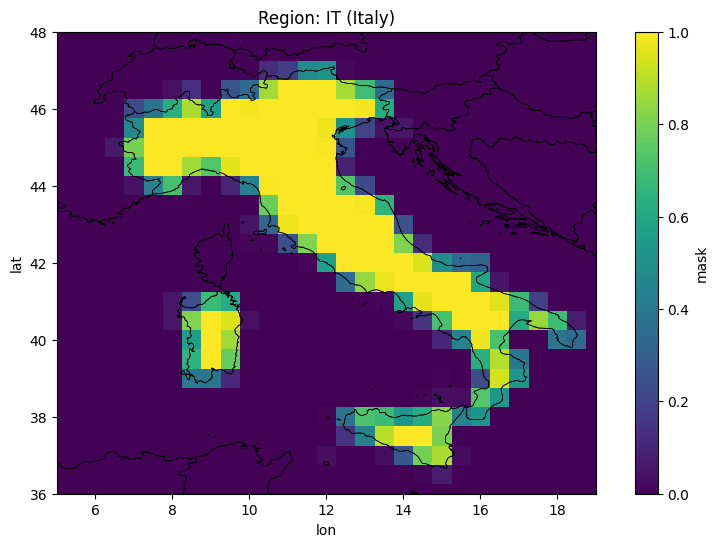

In [11]:
# Open the NetCDF file
da_opened = xr.open_dataarray(mask_file_path)

# Select a region by its INTEGER index (0 to N)
region_id = "IT"

# Use .isel (Index SELect) for integers.
# .sel is for labels (e.g., region='FR')
region_data = da_opened.sel(region=region_id)

# Load the metadata from the NetCDF attribute
metadata_json_str = da_opened.attrs['metadata']
metadata = json.loads(metadata_json_str)

# Find the "NAME" for the given "ID"
region_name = next(
    (item['NAME'] for item in metadata if item['ID'] == region_id),
    "Unknown"
)

# Create a custom colormap
colors = [plt.cm.viridis(i) for i in range(1, 255)]
custom_cmap = ListedColormap(colors)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the selected data
region_data.plot(ax=ax, cmap=custom_cmap, vmin=0, vmax=1, add_colorbar=True)

# Plot shapefile boundaries for context
gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)

# Optional: Zoom
ax.set_xlim(5, 19)
ax.set_ylim(36, 48)

ax.set_title(f'Region: {region_id} ({region_name})')
plt.savefig("single_region_plot.png", format='png', bbox_inches='tight', dpi=150)
plt.show()

### Check the sum of each fractional value

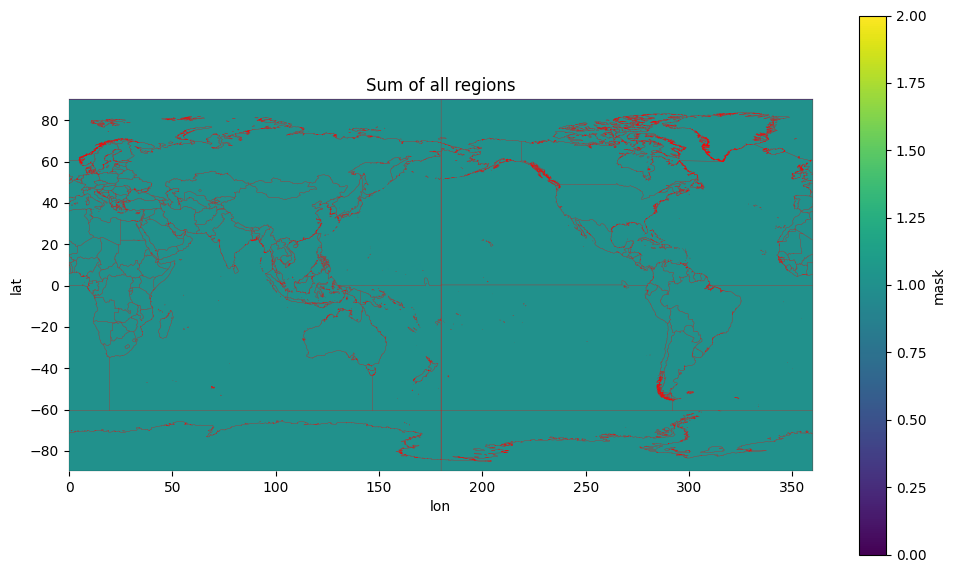

In [12]:
# Create the DataArray with the non-normalized data
da_non_normalized = xr.DataArray(
    raster_3d,
    dims=('region', 'lat', 'lon'),
    coords={
        'region': region_ids,
        'lat': y_coords,
        'lon': x_coords
    },
    name="mask",
    attrs={
        'transform': tuple(transform),
        'crs': str(gdf.crs),
        'resolution': resolution,
        'description': 'Fractional coverage of regions (0.0 to 1.0)',
        'metadata': metadata
    }
)

# Simplify geometries to reduce PDF file size (tolerance is in degrees)
gdf_simple = gdf.copy()
gdf_simple['geometry'] = gdf.simplify(tolerance=0.05, preserve_topology=False)

# Plot with fixed color range from 0 to 1 and custom colormap
fig, ax = plt.subplots(figsize=(12, 7))
da_non_normalized.sum(dim='region').plot(vmin=0, vmax=2, robust=False)

# Plot simplified shapes
gdf_simple.boundary.plot(ax=ax, color='red', linewidth=0.1)

# Thin down the box borders (spines)
# Standard width is usually 1.0; 0.1 is very thin.
for spine in ax.spines.values():
    spine.set_linewidth(0.1)

ax.set_title("Sum of all regions")
plt.savefig("sum_of_regions.png", format='png', bbox_inches='tight', dpi=150)
plt.savefig("sum_of_regions.pdf", format='pdf', bbox_inches='tight')
plt.show()